In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

In [3]:
df = pd.read_csv("../data/processed/merged/merged_data.csv",parse_dates=['Date'], index_col='Date') 

# 1.Basic Overview 

In [4]:
df.head()

,gold_close,gold_high,gold_low,gold_open,gold_vol,dxy_close,vix_close,yield_close,sp500_close,oil_close
Date,,,,,,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138,91.080002,17.790001,2.123,2058.199951,52.689999
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470,91.379997,19.920000,2.039,2020.579956,50.040001
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97,91.500000,21.120001,1.963,2002.609985,47.930000
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29,91.889999,19.309999,1.954,2025.900024,48.650002
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92,92.370003,17.010000,2.016,2062.139893,48.790001


In [5]:
print(f"shape = {df.shape}")

shape = (2825, 10)


In [6]:
print(df.dtypes)

gold_close     float64
gold_high      float64
gold_low       float64
gold_open      float64
gold_vol         int64
dxy_close      float64
vix_close      float64
yield_close    float64
sp500_close    float64
oil_close      float64
dtype: object


In [7]:
df.isnull().sum()

gold_close     0
gold_high      0
gold_low       0
gold_open      0
gold_vol       0
dxy_close      0
vix_close      0
yield_close    0
sp500_close    0
oil_close      0
dtype: int64

In [8]:
print(df.duplicated().sum())

0


In [9]:
df.describe().T.round(2) # Basic Statistics

,count,mean,std,min,25%,50%,75%,max
gold_close,2825.0,1837.23,796.80,1050.80,1273.70,1719.50,1955.30,5318.40
gold_high,2825.0,1847.05,804.89,1062.00,1279.20,1728.10,1963.50,5586.20
gold_low,2825.0,1827.13,788.63,1046.20,1269.90,1708.70,1945.30,5301.60
gold_open,2825.0,1837.09,797.44,1053.70,1274.40,1718.80,1953.20,5415.70
gold_vol,2825.0,5136.59,28054.73,0.00,53.00,207.00,642.00,386334.00
dxy_close,2825.0,98.32,4.82,88.59,94.83,97.62,101.74,114.11
vix_close,2825.0,18.38,7.09,9.14,13.62,16.60,21.29,82.69
yield_close,2825.0,2.68,1.14,0.50,1.78,2.41,3.83,4.99
sp500_close,2825.0,3685.90,1393.23,1829.08,2508.24,3348.42,4499.38,6978.60
oil_close,2825.0,62.46,17.37,-37.63,49.63,61.50,73.17,123.70


# 2.Distribution Analysis

In [10]:
cols = ['gold_close','dxy_close','vix_close','yield_close','sp500_close','oil_close']

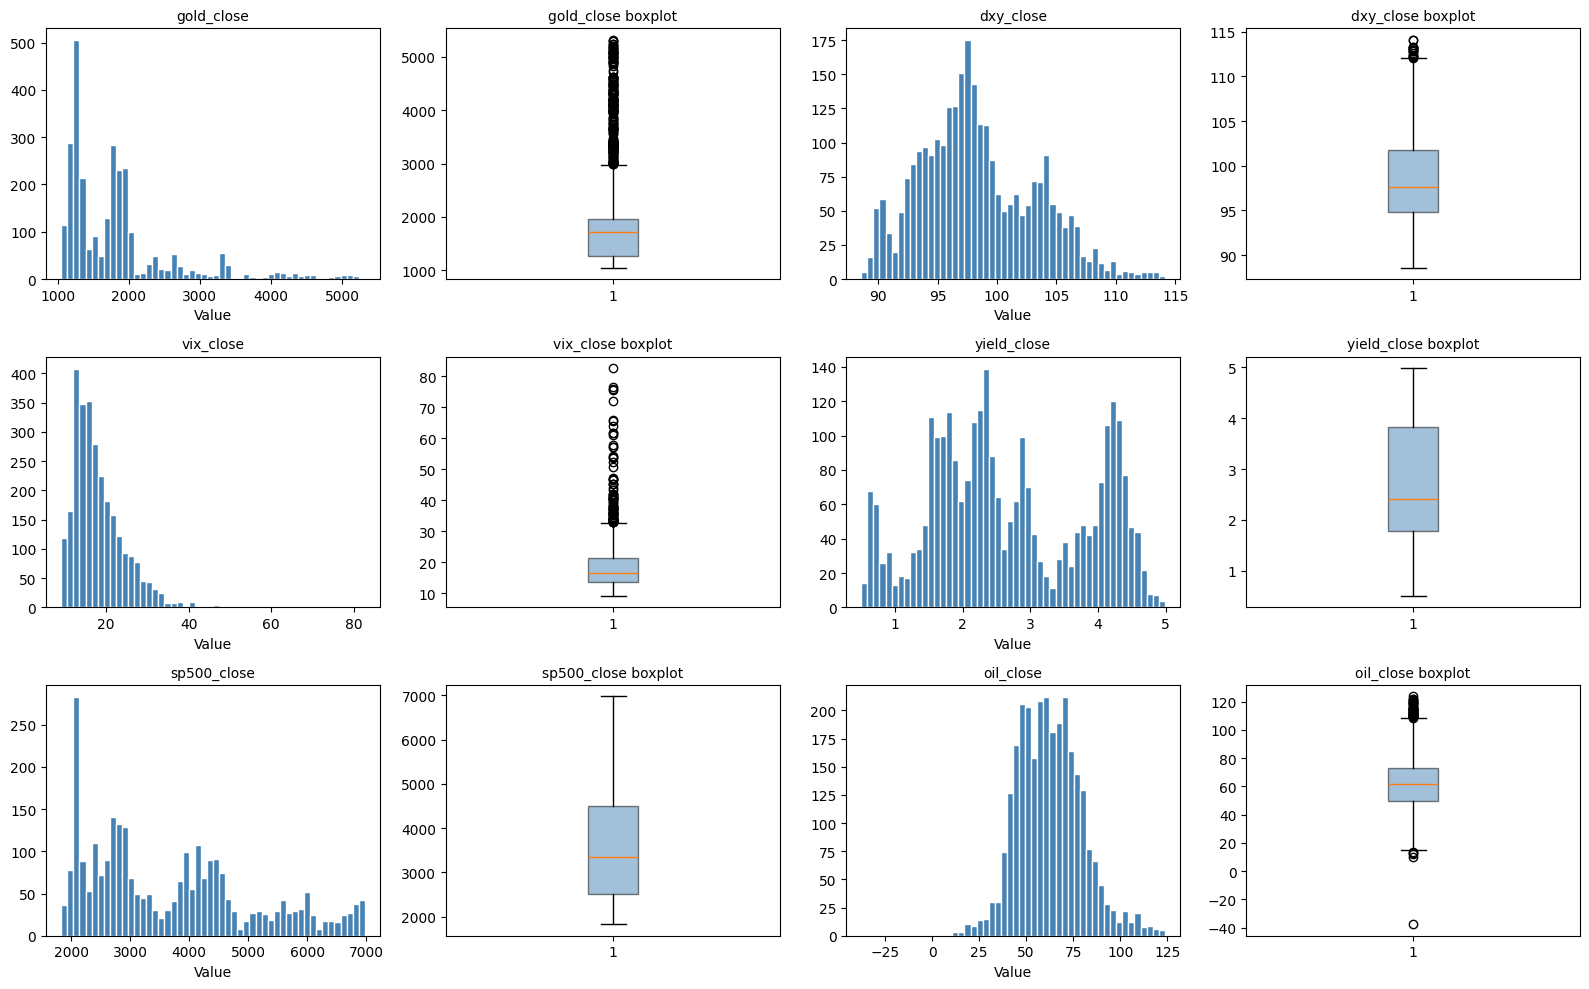

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    # Histogram
    axes[i*2].hist(df[col].dropna(), bins=50, edgecolor='white', color='steelblue')
    axes[i*2].set_title(col, fontsize=10)
    axes[i*2].set_xlabel('Value')

    # Boxplot
    axes[i*2+1].boxplot(df[col].dropna(), patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i*2+1].set_title(f'{col} boxplot', fontsize=10)

plt.tight_layout()
plt.show()

### Skewness & Kurtosis

- Skewness = ดูความเบ้

    ค่า = 0 -> ข้อมูลสมมาตร 

    ค่า > 0 -> ข้อมูลเบ้ขวา -> ยิ่งมาก -> ยิ่งมี outlier ด้านขวาเยอะ

    ค่า < 0 -> ข้อมูลเบ้ซ้าย -> ยิ่งติดลบมาก -> ยิ่งมี outlier ด้านซ้ายเยอะ
    
โดยถ้า |ค่า skewness| 

        ใกล้ 0 = ดี / สมมาตร

        -0.5 ถึง 0.5 = ค่อนข้างปกติ

        0.5 ถึง 1 = เบ้พอสมควร

        มากกว่า 1 =	เบ้มาก

        มากกว่า 2 = เบ้รุนแรง


- Kurtosis = ดูว่าข้อมูลมี outlier เยอะแค่ไหน

    Kurtosis = 0 ->ใกล้เคียง Normal Distribution -> ดี

    Kurtosis > 0 -> ยอดแหลม,หางหนัก -> ยิ่งมาก -> outlier เยอะ

    Kurtosis < 0 -> ยอดแบน,หางเบา -> ยิ่งติดลบมาก -> outlier น้อย -> ข้อมูลนิ่ง
    


In [12]:
print("Skewness & Kurtosis:")
for col in cols:
    sk = df[col].skew()
    ku = df[col].kurtosis()
    print(f"  {col:<20} skew={sk:+.2f}  kurt={ku:+.2f}")

Skewness & Kurtosis:
  gold_close           skew=+2.01  kurt=+4.24
  dxy_close            skew=+0.47  kurt=-0.20
  vix_close            skew=+2.60  kurt=+13.14
  yield_close          skew=+0.15  kurt=-1.09
  sp500_close          skew=+0.66  kurt=-0.58
  oil_close            skew=+0.34  kurt=+0.76


* ผลการวิเคราะห์

        gold_close   -> เบ้ขวามาก เเละ มี outlier มาก        
        dxy_close    -> ปกติ        
        vix_close    -> เบ้ขวามาก เเละ มี outlier มากๆๆๆ         
        yield_close  -> ปกติ
        sp500_close  -> เบ้ขวาเล็กน้อย
        oil_close    -> ปกติ เเละ มี outlier บ้าง

In [13]:
# Outlier count (IQR method)
print("\nOutliers (IQR method):")
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f"  {col:<20} {n_out} rows")


Outliers (IQR method):
  gold_close           262 rows
  dxy_close            17 rows
  vix_close            91 rows
  yield_close          0 rows
  sp500_close          0 rows
  oil_close            46 rows


# 3.Time Series Analysis

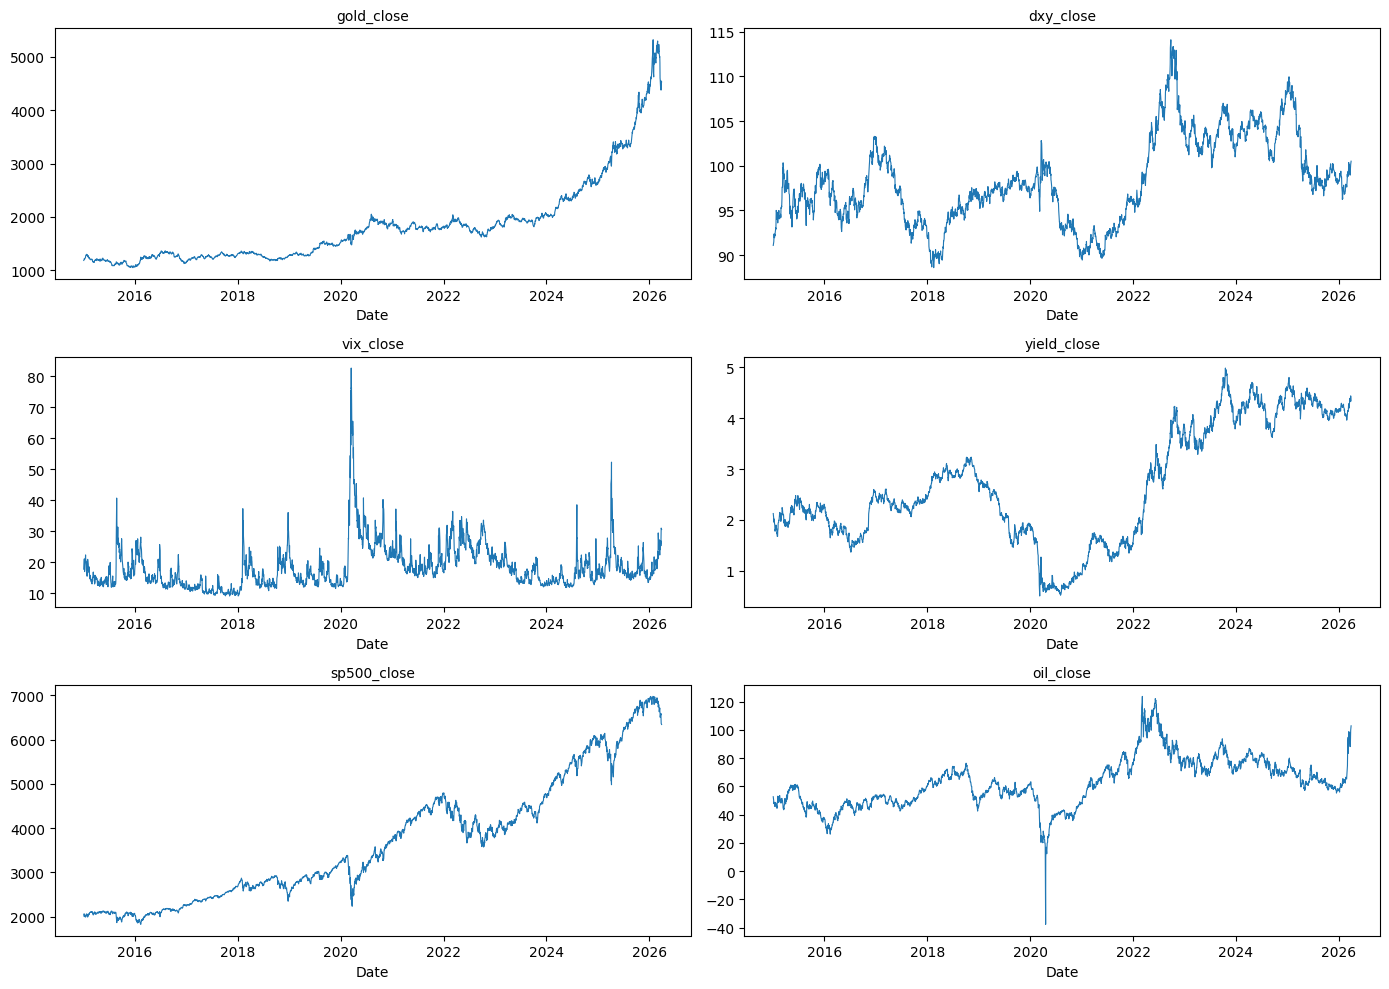

In [14]:
# Plot price over time
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cols):
    axes[i].plot(df.index, df[col], linewidth=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Date')
plt.tight_layout()
plt.show()


* สรุป graph Price Over Time เเต่ละอัน

        -gold เเนวโน้มในระยะยาวเป็นขาขึ้น โดยตั้งเเต่ปี 2024 เป็นต้นมาจะสังเกตุได้ว่าราคาพุ่งขึ้นอย่างรวดเร็วมาก

        -dxy ผันผวนสูง

        -vix มีช่วงพุ่งสูงเป็นระยะๆ เเละในช่วงประมาณ 2020 พุ่งสูงมาก ซึ่งตรงกับการลดลงของราคาในตลาด s&p500

        -yield โดยปกติถ้า yield สูง ราคาทองจะต้องลดลง เเต่ตั้งเเต่ในช่วงของปี 2024 ราคาทองสูงขึ้นในขณะที่ yield ยังคงลอยตัวสูงเท่าๆเดิม

        -sp500 เเนวโน้มในระยะยาวเป็นขาขึ้น

        -oil มีช่วงที่ลงต่ำผิดปกติ ซึ่งเป็นจุดที่เเสดงให้เห็นถึงมีจุด Outlier ที่ชัดเจนมากตรงกับในปี 2020  เเละมีช่วงที่อยู่ดีๆพุ่งเร็วมาก ซึ่งราคาน้ำมันมักเป็นตัวแทนของทิศทาง "เงินเฟ้อ" (Inflation) ซึ่งทองคำมักถูกใช้เป็นสินทรัพย์ป้องกันเงินเฟ้อ

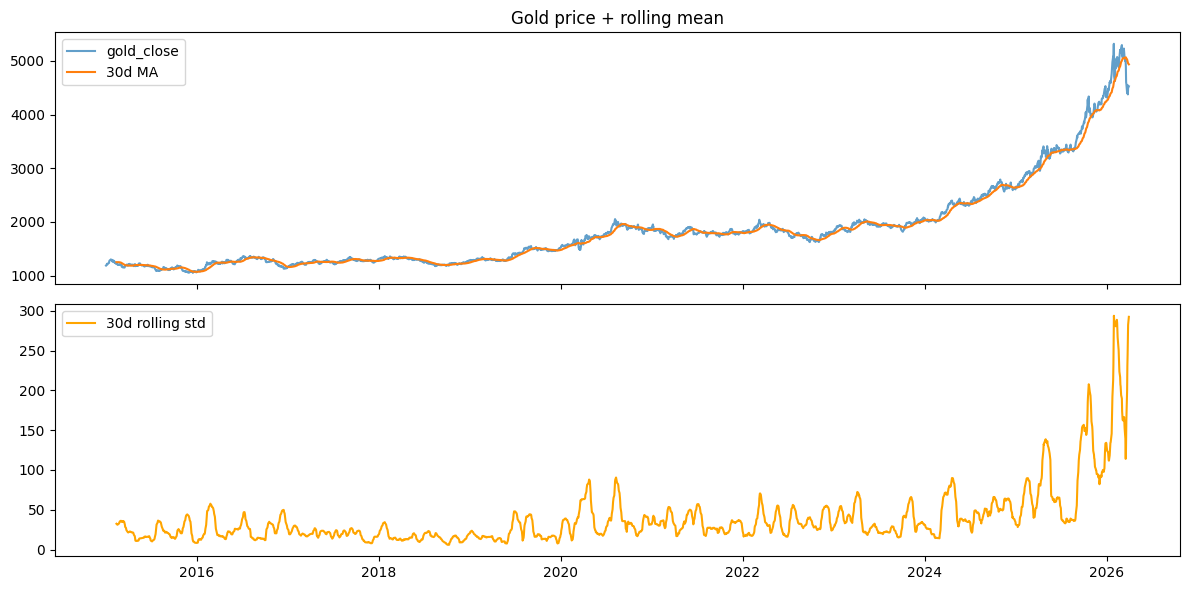

In [15]:
# Gold with rolling mean & std
window = 30
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(df['gold_close'], label='gold_close', alpha=0.7)
axes[0].plot(df['gold_close'].rolling(window).mean(), label=f'{window}d MA', linewidth=1.5)
axes[0].legend()
axes[0].set_title('Gold price + rolling mean')

axes[1].plot(df['gold_close'].rolling(window).std(), color='orange', label=f'{window}d rolling std')
axes[1].legend()
plt.tight_layout()
plt.show()

* กราฟ 30d MA

    จากกราฟจะเห็นได้ว่าราคาของทองเมื่อวิ่งออกจากเส้น 30d MA หรือ กราฟเส้นเฉลี่ยราคาทอง 30 วัน จะมีเเนวโน้มดึงกลับเข้าหาเส้น 30 d MA เสมอ

* กราฟ 30d rolling mean std

    จากกราฟจะเห็นได้ว่าในช่วงปี 2015 ถึงปลายปี 2024 จะยังมีค่า S.D. ในข่วงประมาณเดิม เเต่หลังจากนั้นช่วงปี 2024-2026 มีค่า S.D. ที่ขึ้นลงสูงมาก ซึ่งเเสดงให่้เห็นถึงความผันผวนของราคาทองที่สูงมาก


In [16]:
# ADF Test (Stationarity)
print("ADF Test (Stationarity):")
for col in cols:
    res = adfuller(df[col].dropna())
    stat = "Stationary" if res[1] < 0.05 else "Non-stationary"
    print(f"  {col:<20} p={res[1]:.4f}  → {stat}")

ADF Test (Stationarity):
  gold_close           p=0.9991  → Non-stationary
  dxy_close            p=0.1383  → Non-stationary
  vix_close            p=0.0000  → Stationary
  yield_close          p=0.8194  → Non-stationary
  sp500_close          p=0.9618  → Non-stationary
  oil_close            p=0.3278  → Non-stationary


* ADF Test คือตัววัดความนิ่ง(stationary)ของข้อมูล โดยที่ความนิ่ง คือ ข้อมูลที่มีคุณสมบัติทางสถิติคงที่เมื่อเวลาผ่านไป

    ซึ่งจะดูว่าข้อมูลชุดนั้นนิ่งหรือไม่นิ่งดูจากค่า p-value โดยถ้า p<0.05 จะเเสดงว่าข้อมูลนนั้น stationary หรือ นิ่งนั่นเอง 
    
    โดยจากผลลัพธ์พบว่ามีเเค่ข้อมูล vix_close เท่านั้นที่ stationary เเต่ในส่วนชุดข้อมูลอื่นๆเป็น non-stationary ซึ่งเป็นปกติสำหรับข้อมูลราคาสินทรัพย์เเละในส่วนของเปอร์เซ็นต์ผลตอบเเทนพันธบัตรรัฐบาลสหรัฐ อายุ 10 ปี (US 10-Year Treasury Yield)

# 4.Correlation Analysis

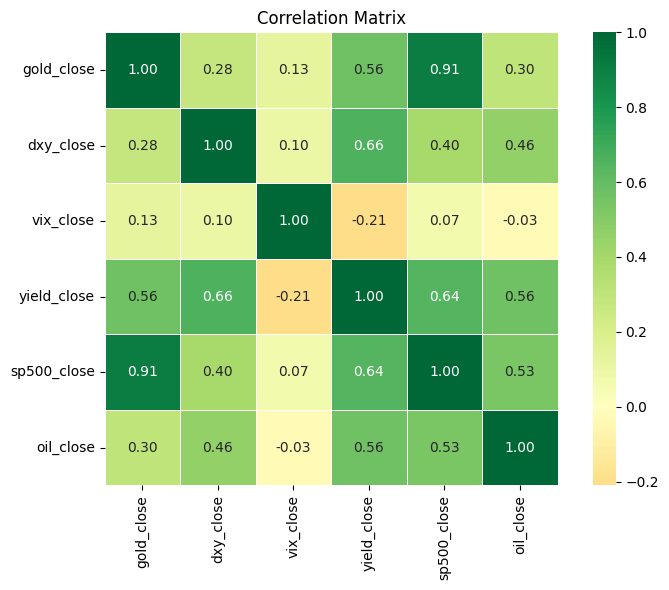

In [17]:
# Correlation matrix heatmap
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

* Correlation matrix heatmap
จากกราฟพบว่า
1. เมื่อผลตอบแทนพันธบัตรรัฐบาล (Yield) สูงขึ้น มักจะดึงดูดเม็ดเงินลงทุนเข้าประเทศ ทำให้ค่าเงินดอลลาร์ (DXY) แข็งค่าตามไปด้วย การที่สองตัวนี้มีความสัมพันธ์กันปานกลางค่อนข้างสูงอาจจะต้องระวังเรื่อง Multicollinearity (ตัวแปรต้นมีความสัมพันธ์กันเองสูงเกินไปจนโมเดลสับสน)
2. Vix ไม่ขึ้นอยู่กับข้อมูลชนิดอื่นๆเนื่องจากมีค่า Correlation กับชุดข้อมูล ที่ต่ำมากๆ
3. gold กับ s&p500 มีความสัมพันธ์ที่สูงมาก เเต่เนื่องจากถ้าดู trend ในระยะยาวจะพบว่าเป็นขาขึ้นเหมือนกัน นั่นคงเป็นเหตุผลที่ว่ามีค่า correlation สูงถึง 0.91

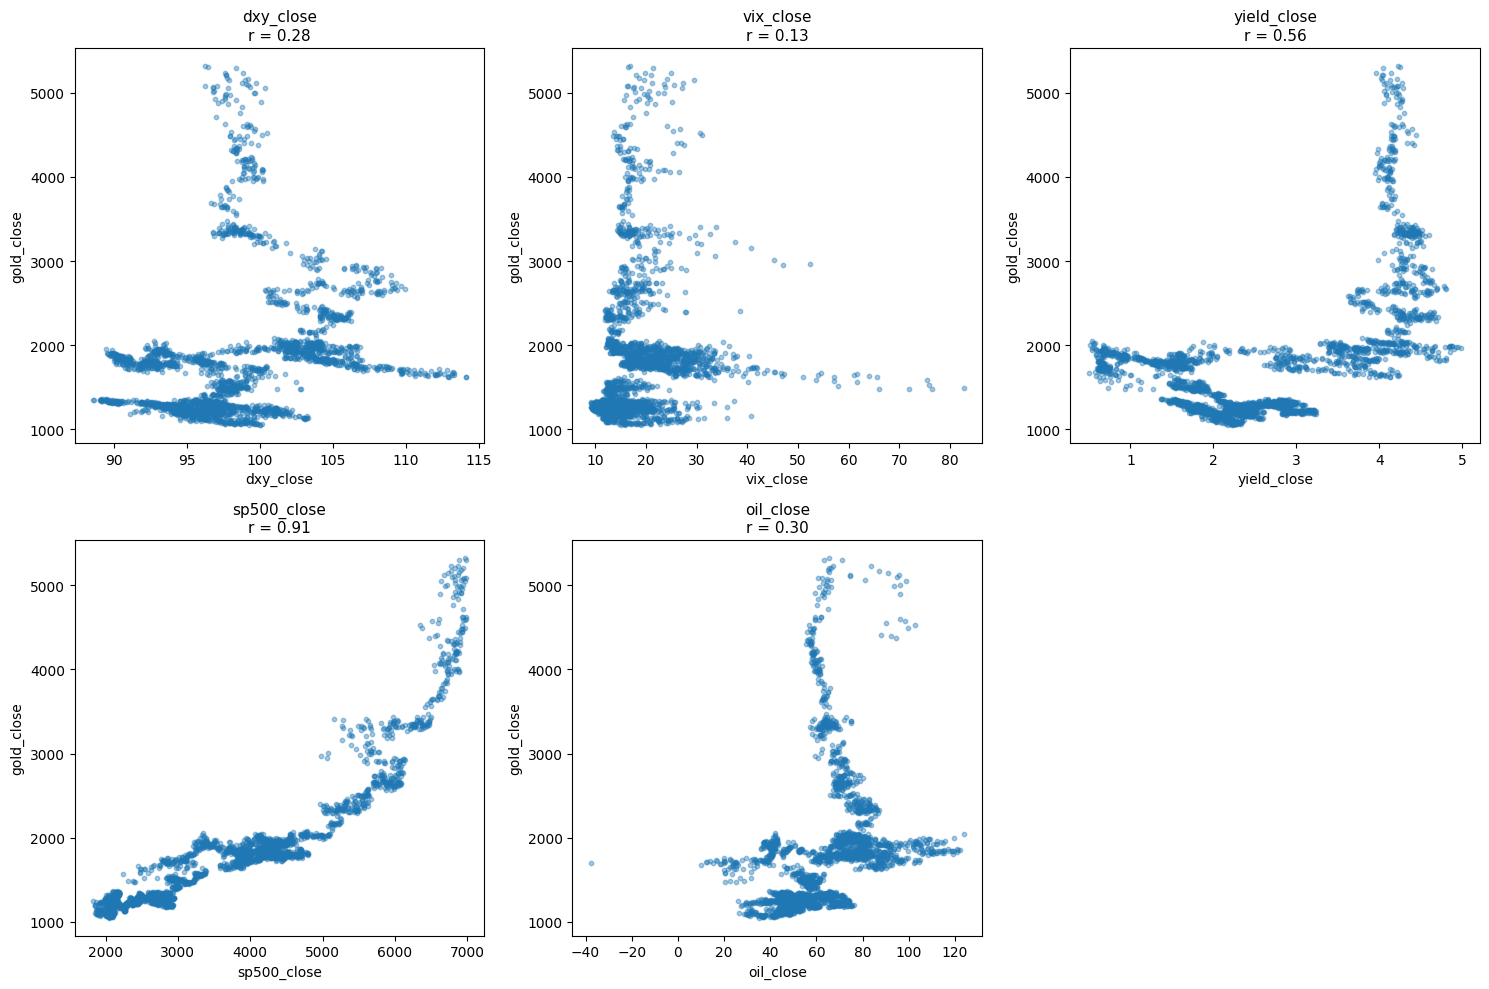

In [ ]:
# Scatter plots: gold vs others 
other_cols = [c for c in cols if c != 'gold_close']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(other_cols):
    axes[i].scatter(
        df[col],
        df['gold_close'],
        alpha=0.4,
        s=10
    )

    r, p = stats.pearsonr(
        df[col].dropna(),
        df['gold_close'].loc[df[col].notna()]
    )

    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('gold_close', fontsize=10)
    axes[i].set_title(f'{col}\nr = {r:.2f}', fontsize=11)

# ถ้ามีช่องว่างเหลือ ให้ลบทิ้ง
for j in range(len(other_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* จาก Scatter Plot 
1. ในส่วนของ dxy กับ gold ข้อมูลไม่ได้เรียงเป็นเส้น แต่เกาะกลุ่มกันเป็นก้อนๆ (Clusters) แปลว่าความสัมพันธ์ของดอลลาร์กับทองคำนั้นเปลี่ยนไปมาตามยุคสมัย ไม่สามารถใช้กฎตายตัวข้อเดียวมาอธิบายได้
2. ในส่วนของ s&p500 กับ gold จะสังเกตุเห็นว่าปลายกราฟด้านบนขวา ราคาทองคำพุ่งทะยานขึ้นอย่างรวดเร็วเกือบจะเป็นแนวตั้งฉาก ในขณะที่ดัชนี SP500 แทบไม่ได้ขยับไปทางขวาเพิ่มขึ้นเท่าไหร่เลย ทำให้เห็นได้ว่าความสัมพันธ์ของ 2 สิ่งนี้เปลี่ยนไปแล้วในช่วงหลัง ซึ่งอาจจะไม่สามารถใช้ Linear Regression ตรงๆได้
3. ปกติตามทฤษฎีคือ ถ้า yield ขึ้น ทองต้องลง แต่จากกราฟพบว่า ทางขวาสุดของกราฟ เรียงกันเป็นเเท่งเเนวตั้ง นั่นคือช่วงที่yield พุ่งไปแตะระดับ 4-5% (สูงมาก) แต่ราคาทองคำกลับไม่ได้ลงลดลงเลย เเต่กลับพุ่งสวนขึ้นไปทำ All-time High นี่คือสัญญาณว่าตลาดมีสภาวะที่แปลกไป
4. มีในส่วนของ oil ที่เห็นว่าเป็น outllier 1 จุดได้อย่างชัดเจน คือตรงในส่วนที่เเกน x มีค่าอยู่ที่ประมาณ -40 (อย่าลืมลบค่าตรงนี้ออกก่อนไป train)

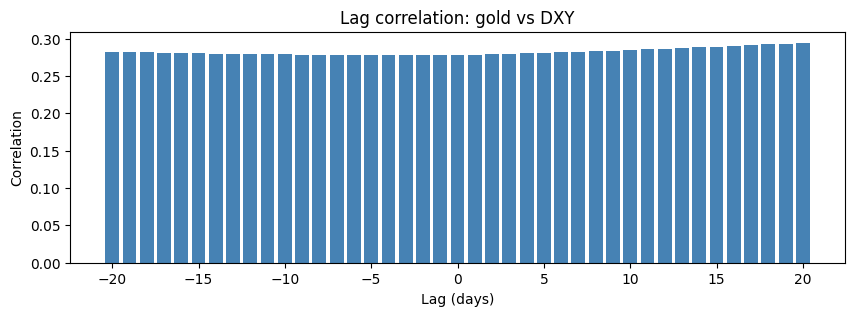

In [19]:
# Lag correlation: gold vs dxy (up to 20 lags)
lags = range(-20, 21)
lag_corr = [df['gold_close'].corr(df['dxy_close'].shift(lag)) for lag in lags]
plt.figure(figsize=(10, 3))
plt.bar(lags, lag_corr, color=['red' if x < 0 else 'steelblue' for x in lag_corr])
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Lag (days)')
plt.ylabel('Correlation')
plt.title('Lag correlation: gold vs DXY')
plt.show()

* Lag correlation
1. จะเห็นว่าไม่ว่าจะเลื่อน (Shift) ข้อมูล DXY ไปข้างหน้า (Lag บวก) หรือย้อนหลัง (Lag ลบ) ตั้งแต่ -20 ถึง +20 วัน ค่าความสัมพันธ์มันแทบจะเท่ากันหมดเลย คือกองๆ กันอยู่ที่ประมาณ $0.28$ ถึง $0.29$ ไม่มีแท่งไหนที่โดดเด่น (Spike) ขึ้นมาอย่างชัดเจนเลย

สิ่งที่ควรเเก้ คือ ต้องแปลงข้อมูลราคา ให้เป็น % Return หรือผลต่างรายวัน (Differencing) ก่อนทำ Lag Correlation 

# 5.Volatility Analysis

In [28]:
# Daily returns
df['gold_return'] = df['gold_close'].pct_change()
df['sp500_return'] = df['sp500_close'].pct_change()

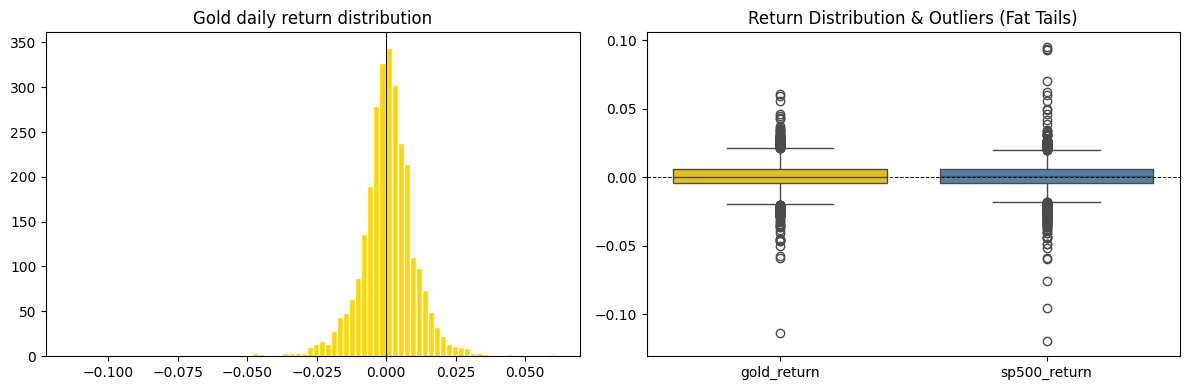

In [ ]:
# Histogram & Boxplot of returns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gold daily return distribution (โค้ดเดิมของคุณ)
axes[0].hist(df['gold_return'].dropna(), bins=80, edgecolor='white', color='gold')
axes[0].set_title('Gold daily return distribution')
axes[0].axvline(0, color='black', linewidth=0.7)

# Boxplot เปรียบเทียบความผันผวนและ Outliers
sns.boxplot(data=df[['gold_return', 'sp500_return']].dropna(), ax=axes[1], palette=['gold', 'steelblue'])
axes[1].set_title('Return Distribution & Outliers (Fat Tails)')
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--') 

plt.tight_layout()
plt.show()

* จากกราฟ Histogram of return
1. พบว่ากราฟจะดูคล้ายระฆังคว่ำ แต่ฐานที่ลากยาวออกไปซ้ายขวามากกว่าปกติ เช่น วันที่มีข่าวสงคราม Return อาจจะกระโดดไป +3% หรือ -3% ในวันเดียว(-0.03 กับ 0.03) ซึ่งเป็นจุดที่โมเดล Regression มักจะทำนายพลาดเพราะมันเป็น Extreme Events
2. อาจส่งผลกระทบต่อโมเดล classification เนื่องจากถ้า return มากกว่า 0 เพียงเเค่ 0.01 โมเดลจะมองว่าเป็นขาขึ้นในทันที ดังนั้นควรกำหนด range ของ %return ใหม่
3. อาจส่งผลต่อโมเดล regression ในการทำนายเนื่องจากมีค่าประมาณ0 อยู่มากดังนั้นโมเดลอาจทำนายว่าเป็น 0เพื่อจะใหม่มีค่า RMSE ต่ำ

* Boxplot of returns
1. ตรงกลางของ Boxplot จะเห็นว่าทั้ง gold_return และ sp500_return มีขนาดกล่องที่แบนและแคบมาก เกาะอยู่ติดกับเส้น 0.0 ทั้งคู่ เเสดงว่าในช่วงเวลา 50% ของวันทำการปกติ (P25 ถึง P75) ตลาดแทบจะไม่มีการเปลี่ยนแปลงที่ผันผวนสูงเลย ซึ่งประมาณได้ว่าราคาทองและหุ้นขยับขึ้นลงในกรอบแคบๆ ไม่ถึง 1% ต่อวันด้วยซ้ำ

2. The Outliers & Fat Tails -> S&P 500 มีราคาที่เหวี่ยงแรงกว่าทองคำ คุณจะเห็นว่าจุด Outliers ของ sp500_return กระจายตัวกว้างมาก มีวันที่ดิ่งลงไปลึกสุดเกือบ -0.12 (-12%) และพุ่งขึ้นไปเกือบ 0.10 (+10%)
ซึ่งจะเห็นได้ว่าทองคำปลอดภัยกว่า แต่ก็มีราคาลดบ้างเหมือนกัน แม้ gold_return จะมีความผันผวนน้อยกว่าหุ้น แต่ก็มีวันวิกฤตที่ดิ่งลงไปถึงระดับ -0.11 (-11%) เช่นกัน 

#### Note for Feature Engineering
สร้างตัวแปรใหม่ที่เป็นความผันผวนย้อนหลังของ S&P500 (เช่น S&P500 7-day Rolling Standard Deviation) เพื่อให้โมเดลรู้ตัวว่าถ้าช่วงนี้ตลาดหุ้นแกว่งตัวรุนแรง โอกาสที่ทองคำจะพุ่งแรงก็มีสูงตามไปด้วย

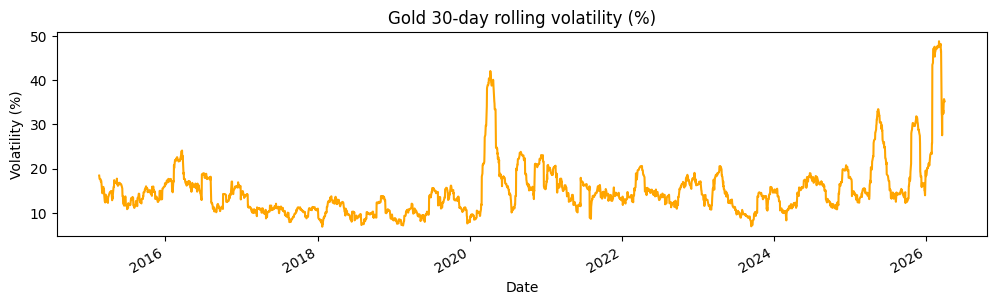

In [23]:

# Rolling volatility (annualized)
df['gold_vol_30d'] = df['gold_return'].rolling(30).std() * np.sqrt(252) * 100
df['gold_vol_30d'].plot(figsize=(12, 3), color='orange', title='Gold 30-day rolling volatility (%)')
plt.ylabel('Volatility (%)')
plt.show()


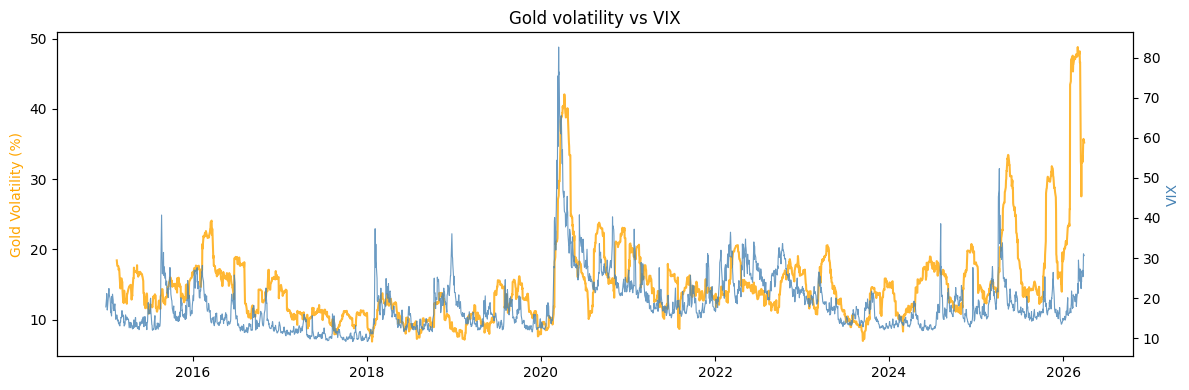

In [24]:
# Gold volatility vs VIX
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.plot(df.index, df['gold_vol_30d'], color='orange', label='Gold vol 30d', alpha=0.8)
ax2.plot(df.index, df['vix_close'], color='steelblue', label='VIX', alpha=0.8, linewidth=0.8)
ax1.set_ylabel('Gold Volatility (%)', color='orange')
ax2.set_ylabel('VIX', color='steelblue')
plt.title('Gold volatility vs VIX')
plt.tight_layout()
plt.show()

In [25]:
# Return stats
r = df['gold_return'].dropna()
print(f"Mean return:  {r.mean()*100:.4f}%")
print(f"Std:          {r.std()*100:.4f}%")
print(f"Sharpe (ann): {(r.mean()/r.std())*np.sqrt(252):.2f}")
print(f"Max drawdown: {(df['gold_close']/df['gold_close'].cummax()-1).min()*100:.2f}%")

Mean return:  0.0527%
Std:          1.0264%
Sharpe (ann): 0.82
Max drawdown: -20.87%
